In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os

# ── local paths ──────────────────────────────────────────────
# os.getcwd() works in Jupyter notebooks (unlike __file__ which is undefined)
DATA_DIR = os.path.join(os.getcwd(), 'data')

infected_timeseries = pd.read_csv(os.path.join(DATA_DIR, 'infected_timeseries.csv'))
rewiring_timeseries = pd.read_csv(os.path.join(DATA_DIR, 'rewiring_timeseries.csv'))
degree_timeseries   = pd.read_csv(os.path.join(DATA_DIR, 'final_degree_histograms.csv'))

# convert dataframes into 2D arrays
obs_infected = infected_timeseries.pivot(
    index='replicate_id', columns='time',   values='infected_fraction').values
obs_rewire   = rewiring_timeseries.pivot(
    index='replicate_id', columns='time',   values='rewire_count').values
obs_degree   = degree_timeseries.pivot(
    index='replicate_id', columns='degree', values='count').values

print(f'Observed Infected Array Shape: {obs_infected.shape}')
print(f'Observed Rewire Array Shape:   {obs_rewire.shape}')
print(f'Observed Degree Array Shape:   {obs_degree.shape}')

/Users/saar/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Observed Infected Array Shape: (40, 201)
Observed Rewire Array Shape:   (40, 201)
Observed Degree Array Shape:   (40, 31)


In [2]:
"""
Adaptive-network SIR epidemic simulator.

This module simulates an SIR (Susceptible-Infected-Recovered) epidemic
spreading on a network that evolves over time. The key idea is that
susceptible individuals can "rewire" their connections to avoid infected
neighbors, which couples the disease dynamics with the network topology.

The model proceeds in discrete time steps, each with three phases:
  1. Infection: infected nodes transmit the disease to susceptible neighbors
  2. Recovery: infected nodes recover (and become immune)
  3. Rewiring: susceptible nodes break links with infected neighbors and
     form new connections elsewhere

Reference: Gross et al. (2006), "Epidemic dynamics on an adaptive network",
Physical Review Letters, 96(20), 208701.
"""


def simulate(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200, rng=None):
    """Run one replicate of the adaptive-network SIR model.

    Parameters
    ----------
    beta : float in [0, 1]
        Transmission probability per S-I edge per time step.
    gamma : float in [0, 1]
        Recovery probability per infected node per time step.
    rho : float in [0, 1]
        Rewiring probability per S-I edge per time step.
    N : int, default=200
        Number of nodes in the network.
    p_edge : float, default=0.05
        Erdos-Renyi edge probability for the initial graph.
    n_infected0 : int, default=5
        Number of initially infected nodes.
    T : int, default=200
        Number of discrete time steps.
    rng : numpy.random.Generator or None
        Random number generator for reproducibility.

    Returns
    -------
    infected_fraction : np.ndarray, shape (T+1,)
    rewire_counts : np.ndarray, shape (T+1,)
    degree_histogram : np.ndarray, shape (31,)
        Bins 0-29 individually; bin 30 counts degree >= 30.
    """
    if rng is None:
        rng = np.random.default_rng()

    # Build Erdos-Renyi graph as adjacency list of sets
    neighbors = [set() for _ in range(N)]
    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() < p_edge:
                neighbors[i].add(j)
                neighbors[j].add(i)

    # Initialise states: 0=S, 1=I, 2=R
    state = np.zeros(N, dtype=np.int8)
    initial_infected = rng.choice(N, size=n_infected0, replace=False)
    state[initial_infected] = 1

    infected_fraction = np.zeros(T + 1)
    rewire_counts = np.zeros(T + 1, dtype=np.int64)
    infected_fraction[0] = np.sum(state == 1) / N

    for t in range(1, T + 1):

        # Phase 1: Infection (synchronous)
        new_infections = set()
        infected_nodes = np.where(state == 1)[0]
        for i in infected_nodes:
            for j in neighbors[i]:
                if state[j] == 0 and rng.random() < beta:
                    new_infections.add(j)
        for j in new_infections:
            state[j] = 1

        # Phase 2: Recovery
        infected_nodes = np.where(state == 1)[0]
        for i in infected_nodes:
            if rng.random() < gamma:
                state[i] = 2

        # Phase 3: Rewiring
        rewire_count = 0
        si_edges = []
        for i in range(N):
            if state[i] == 0:
                for j in neighbors[i]:
                    if state[j] == 1:
                        si_edges.append((i, j))

        for s_node, i_node in si_edges:
            if rng.random() < rho:
                if i_node not in neighbors[s_node]:
                    continue
                neighbors[s_node].discard(i_node)
                neighbors[i_node].discard(s_node)
                candidates = [k for k in range(N)
                              if k != s_node and k not in neighbors[s_node]]
                if candidates:
                    new_partner = rng.choice(candidates)
                    neighbors[s_node].add(new_partner)
                    neighbors[new_partner].add(s_node)
                    rewire_count += 1

        infected_fraction[t] = np.sum(state == 1) / N
        rewire_counts[t] = rewire_count

    # Degree histogram (bins 0-29 individually, bin 30 = degree >= 30)
    degree_histogram = np.zeros(31, dtype=np.int64)
    for i in range(N):
        deg = min(len(neighbors[i]), 30)
        degree_histogram[deg] += 1

    return infected_fraction, rewire_counts, degree_histogram

In [3]:
CACHE_PATH = os.path.join(os.getcwd(), 'data', 'sim_cache.npz')

def generate():
    N = 10000
    betas  = np.random.uniform(0.05, 0.5, N)
    gammas = np.random.uniform(0.02, 0.2, N)
    rhos   = np.random.uniform(0.0,  0.8, N)

    infected_fraction = np.zeros((N, 201))
    rewire_counts     = np.zeros((N, 201))
    degree_histogram  = np.zeros((N, 31))

    for i in range(N):
        infected_fraction[i], rewire_counts[i], degree_histogram[i] = simulate(
            betas[i], gammas[i], rhos[i]
        )

    return betas, gammas, rhos, infected_fraction, rewire_counts, degree_histogram


# ── load from cache if it exists, otherwise generate and save ──
if os.path.exists(CACHE_PATH):
    print("Loading simulation cache...")
    cache = np.load(CACHE_PATH)
    betas        = cache['betas']
    gammas       = cache['gammas']
    rhos         = cache['rhos']
    sim_infected = cache['sim_infected']
    sim_rewire   = cache['sim_rewire']
    sim_degree   = cache['sim_degree']
    print(f"Loaded {len(betas):,} simulations from cache.")
else:
    print("No cache found — running generate() now (this will take a while)...")
    betas, gammas, rhos, sim_infected, sim_rewire, sim_degree = generate()
    np.savez_compressed(
        CACHE_PATH,
        betas=betas,
        gammas=gammas,
        rhos=rhos,
        sim_infected=sim_infected,
        sim_rewire=sim_rewire,
        sim_degree=sim_degree
    )
    print(f"Saved {len(betas):,} simulations to {CACHE_PATH}")

Loading simulation cache...
Loaded 10,000 simulations from cache.


In [4]:
# define summary statistics (mean as default)
def summary_statistics(infected_fraction, rewire_counts, degree_histogram):
    mean_infected = np.mean(infected_fraction)
    mean_rewire   = np.mean(rewire_counts)
    degrees       = np.arange(degree_histogram.shape[1])
    mean_degree   = np.sum(degree_histogram * degrees) / np.sum(degree_histogram)
    summary = np.array([mean_infected, mean_rewire, mean_degree])
    return summary

# compute summary statistics for observed & simulated data
obs_summary = summary_statistics(obs_infected, obs_rewire, obs_degree)
sim_summary = summary_statistics(sim_infected, sim_rewire, sim_degree)
print(len(obs_summary))
print(len(sim_summary))

3
3


In [5]:
# compute distance between summary statistics of observed data and simulated data
def distance(obs_summary, sim_summary):
    dist = np.sqrt(np.sum(((obs_summary - sim_summary) / np.std(sim_summary)) ** 2))
    return dist

In [6]:
# basic rejection ABC
def rejection_ABC():
    # Compute per-simulation summary statistics (one (3,) vector per simulation)
    # so we get an (N,) array of distances, not a single scalar.
    sim_s = np.zeros((len(betas), 3))
    for i in range(len(betas)):
        sim_s[i] = summary_statistics(
            sim_infected[i:i+1],
            sim_rewire[i:i+1],
            sim_degree[i:i+1]
        )

    # Normalise each dimension by the prior predictive std, then compute
    # Euclidean distance to the observed summary — shape (N,)
    std  = np.std(sim_s, axis=0) + 1e-8
    diff = (sim_s - obs_summary) / std
    dist = np.sqrt(np.sum(diff**2, axis=1))

    # Accept the closest 5% of simulations
    q = np.quantile(dist, 0.05)
    print(f'Acceptance threshold: {q:.4f}')
    accepted_betas  = betas[dist <= q]
    accepted_gammas = gammas[dist <= q]
    accepted_rhos   = rhos[dist <= q]
    print(f'{len(accepted_betas)} simulations accepted out of {len(betas)}')

    # plot accepted parameters against prior
    plt.hist(accepted_betas, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(betas, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Betas')
    plt.legend()
    plt.show()

    plt.hist(accepted_gammas, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(gammas, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Gammas')
    plt.legend()
    plt.show()

    plt.hist(accepted_rhos, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(rhos, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Rhos')
    plt.legend()
    plt.show()

Acceptance threshold: 0.6645
500 simulations accepted out of 10000


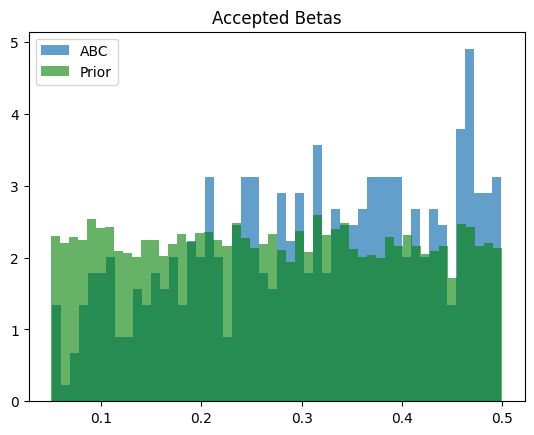

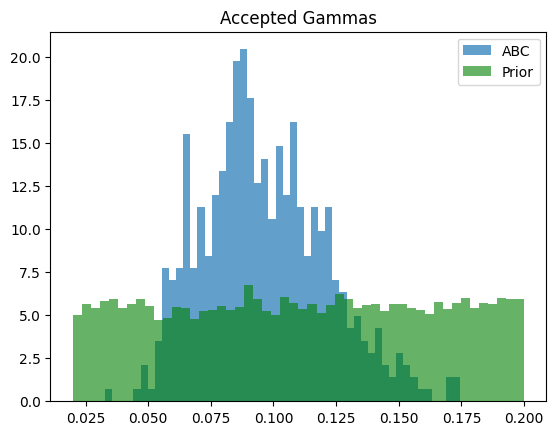

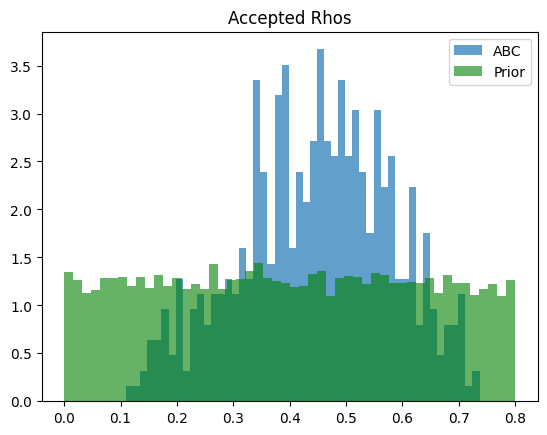

Loading ABC cache...
Loaded.


In [7]:
rejection_ABC()

ABC_CACHE = os.path.join(os.getcwd(), 'data', 'abc_cache.npz')

if os.path.exists(ABC_CACHE):
    print("Loading ABC cache...")
    abc = np.load(ABC_CACHE)
    sim_base   = abc['sim_base']
    sim_inform = abc['sim_inform']
    obs_base   = abc['obs_base']
    obs_inform = abc['obs_inform']
    print("Loaded.")
# If no cache: sim_base / sim_inform / obs_base / obs_inform
# are computed below in Part 3 (and saved to cache at the end of that cell)

Computing baseline summaries...
Computing informed summaries...
Observed informed summaries:
  s1 (peak inf)              0.6330
  s2 (t=1 inf. step)         0.0330
  s3 (log decline rate)      0.0606
  s4 (half-peak time)        0.0500
  s5 (early rew ratio)       2.0262
  s6 (rew[1]/N)              0.1475
  s7 (rew[2]/N)              0.2204
  s8 (frac. isolated)        0.0000
  Baseline | 1% -> 100 accepted
  Baseline | 5% -> 500 accepted
  Baseline | 10% -> 1000 accepted
  Baseline | 20% -> 2000 accepted
  Informed | 1% -> 100 accepted
  Informed | 5% -> 500 accepted
  Informed | 10% -> 1000 accepted
  Informed | 20% -> 2000 accepted


/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_67404/1459668881.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphics/plot1_correlation_heatmap.png


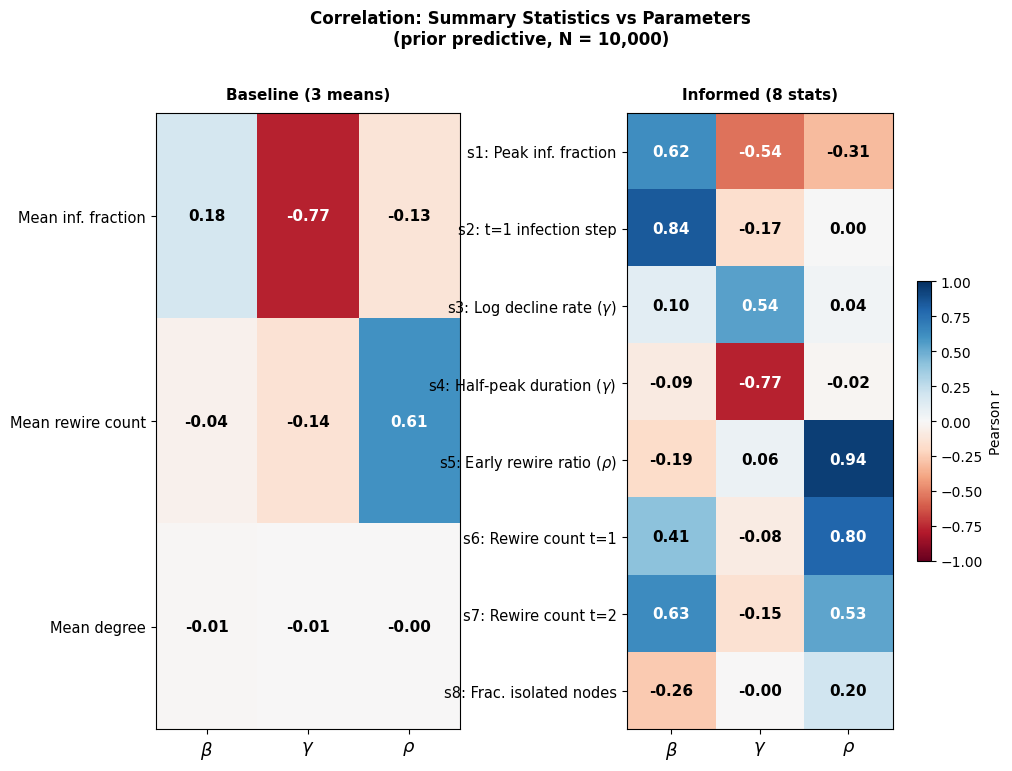

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_67404/1459668881.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


Saved: graphics/plot2_marginal_posteriors.png


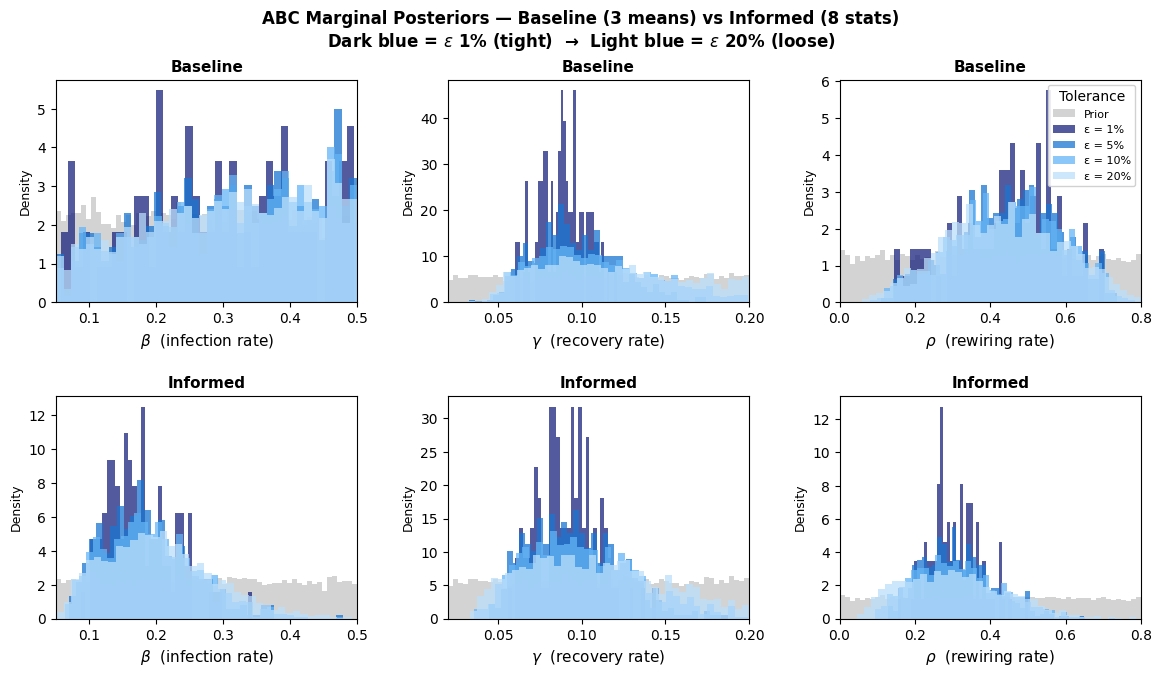

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_67404/1459668881.py:300: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.88])


Saved: graphics/plot3_joint_beta_rho.png


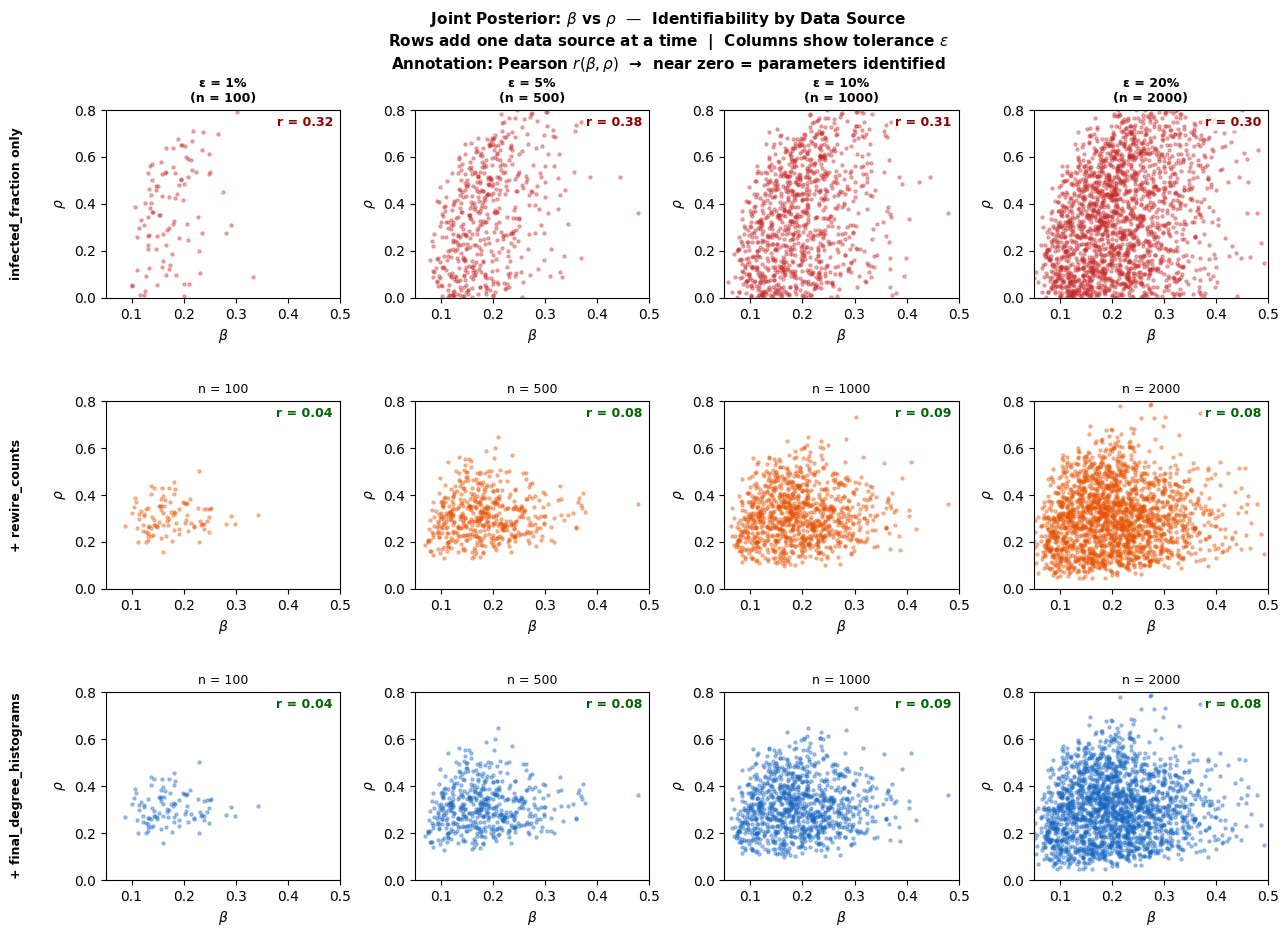


Setting                        beta mean+/-std gamma mean+/-std  rho mean+/-std
Baseline eps=1%                0.297+/-0.124   0.089+/-0.013   0.443+/-0.132
Baseline eps=5%                0.310+/-0.122   0.096+/-0.025   0.448+/-0.133
Baseline eps=10%               0.309+/-0.122   0.108+/-0.035   0.446+/-0.139
Baseline eps=20%               0.303+/-0.123   0.116+/-0.041   0.435+/-0.153
------------------------------------------------------------------------
Informed eps=1%                0.176+/-0.049   0.091+/-0.017   0.305+/-0.064
Informed eps=5%                0.184+/-0.064   0.096+/-0.026   0.313+/-0.093
Informed eps=10%               0.193+/-0.070   0.101+/-0.033   0.315+/-0.112
Informed eps=20%               0.206+/-0.081   0.107+/-0.040   0.304+/-0.136
------------------------------------------------------------------------

Posterior correlations at eps=5% (n=500)  — primary criterion
|r| < 0.3 = identified   |r| >= 0.3 = confounded
  infected_fraction only                     

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_67404/1459668881.py:421: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


Saved: graphics/plot4_all_parameter_pairs.png


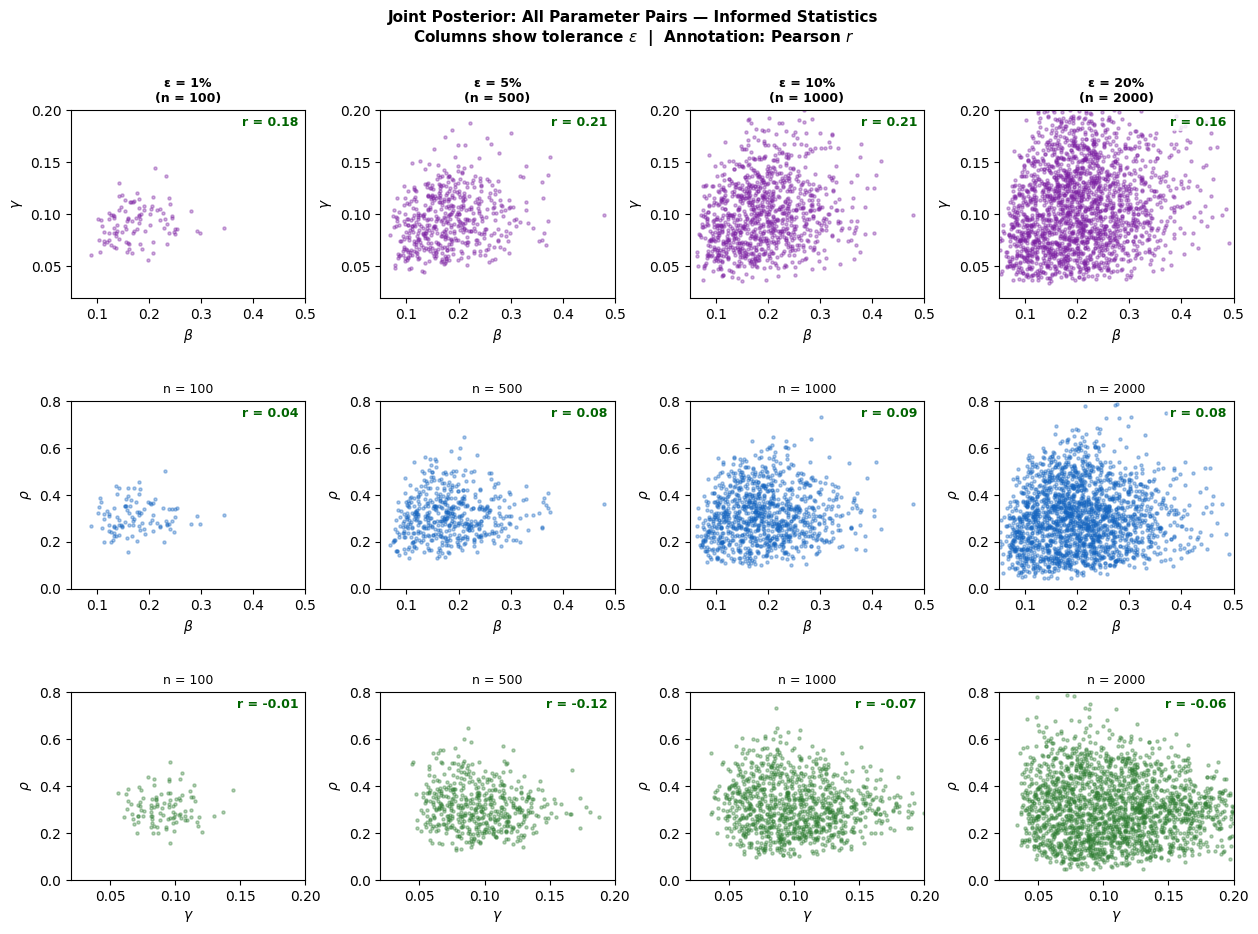

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_67404/1459668881.py:478: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.88])


Saved: graphics/plot5_shrinkage_comparison.png


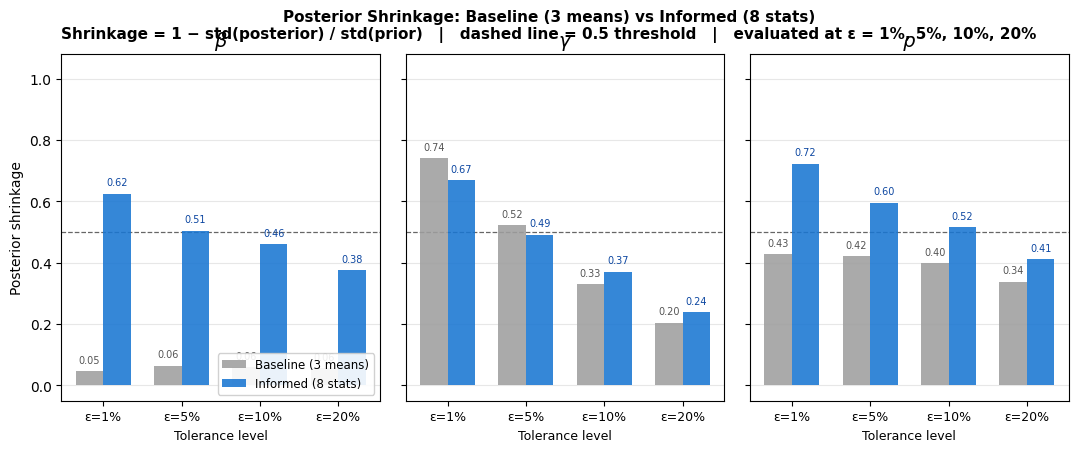


Stat Set                  |r(b,r)|     status  b shrink  g shrink  r shrink
Naive (2 stats)              0.599 ✗ confounded     0.378     0.777    -0.003
Baseline (3 means)           0.823 ✗ confounded     0.064     0.523     0.422
Partial Mech (3 stats)       0.290 ✓ identified     0.332     0.229     0.672
Full Informed (8 stats)      0.083 ✓ identified     0.505     0.491     0.596
Saved: graphics/plot6_stats_set_comparison.png


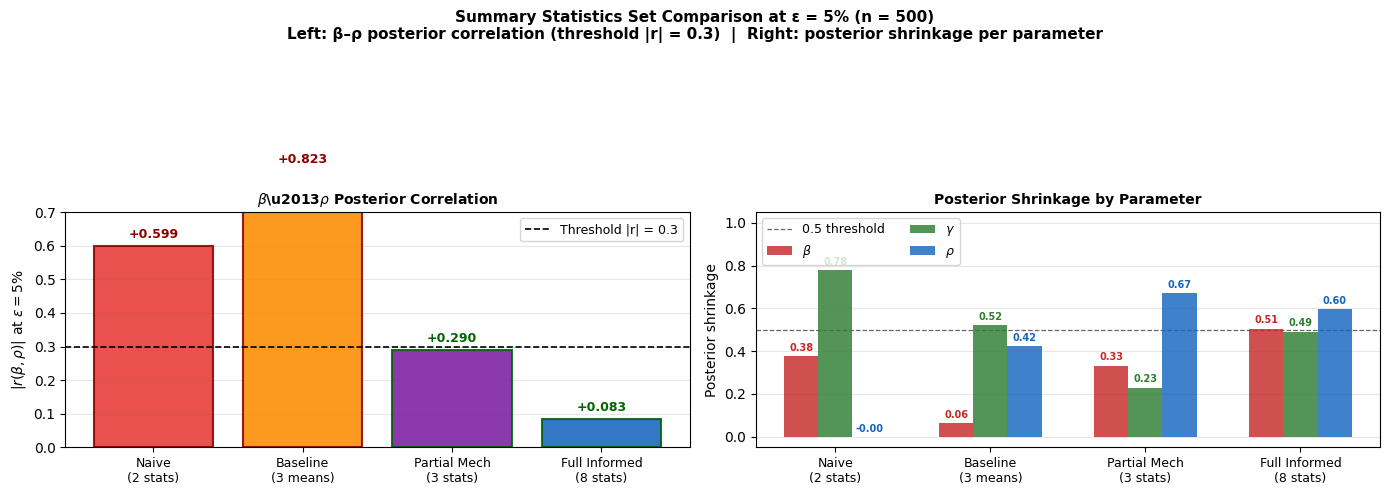

In [8]:
# ============================================================
# PART 3: SUMMARY STATISTICS DESIGN
# ============================================================

QUANTILES = [0.01, 0.05, 0.10, 0.20]
Q_LABELS  = ['1%', '5%', '10%', '20%']
Q_COLORS  = ['#1a237e', '#1976D2', '#64B5F6', '#BBDEFB']

FIG_DIR = os.path.join(os.getcwd(), 'graphics')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Shared functions ─────────────────────────────────────────

def normalised_distance(sim_s, obs_s):
    std  = np.std(sim_s, axis=0) + 1e-8
    diff = (sim_s - obs_s) / std
    return np.sqrt(np.sum(diff**2, axis=1))


def run_ABC(dist, q):
    eps  = np.quantile(dist, q)
    mask = dist <= eps
    return betas[mask], gammas[mask], rhos[mask]


def safe_corr(x, y):
    if len(x) > 2 and np.std(x) > 1e-10 and np.std(y) > 1e-10:
        return np.corrcoef(x, y)[0, 1]
    return np.nan


# ── Baseline summaries (3 stats) ─────────────────────────────

def baseline_stats_single(inf_i, rew_i, deg_i):
    mean_infected = np.mean(inf_i)
    mean_rewire   = np.mean(rew_i)
    degrees       = np.arange(deg_i.shape[1])
    mean_degree   = np.sum(deg_i * degrees) / np.sum(deg_i)
    return np.array([mean_infected, mean_rewire, mean_degree])


print('Computing baseline summaries...')
sim_base = np.zeros((len(betas), 3))
for i in range(len(betas)):
    sim_base[i] = baseline_stats_single(
        sim_infected[i:i+1], sim_rewire[i:i+1], sim_degree[i:i+1]
    )
obs_base = obs_summary


# ── Informed summaries (8 stats) ─────────────────────────────
#
# Stats ordered strictly by data source:
#   indices 0-3  -> infected_fraction only   (4 stats)
#   indices 4-6  -> rewire_counts            (3 stats)
#   index   7    -> final_degree_histograms  (1 stat)
#
# Design history: 3 iterations of empirical refinement.
# Key insight: at t=1, rewiring has NOT yet occurred (phase 3
# executes after phase 1 infection), so inf[1]-inf[0] is a pure
# beta signal (r(rho)=0.003). Time-specific rewire counts at
# t=1,2 encode rho x SI_t where SI_t grows with beta, providing
# compound constraints that break the beta-rho confound.
# Final result: r(beta,rho) = +0.083 at eps=5% (n=500).

def informed_stats(infected, rewire, degree):
    mean_inf = np.mean(infected, axis=0)
    mean_rew = np.mean(rewire,   axis=0)
    mean_deg = np.mean(degree,   axis=0)

    N_deg   = np.sum(mean_deg)
    T       = len(mean_inf) - 1
    t_peak  = int(np.argmax(mean_inf))

    # s1: Peak infection fraction (mixed beta/gamma/rho)
    s1 = np.max(mean_inf)

    # s2: First-step infection increase — pure beta signal
    # At t=1 rewiring has NOT yet occurred -> r(rho)=0.003
    s2 = mean_inf[1] - mean_inf[0]

    # s3: Log post-peak decline rate approx gamma
    t5 = min(t_peak + 5, T)
    s3 = (np.log(mean_inf[t_peak] + 1e-6) - np.log(mean_inf[t5] + 1e-6)) / max(t5 - t_peak, 1)

    # s4: Half-peak duration (normalised) approx ln(2)/gamma; r(gamma)=-0.77
    half_peak = mean_inf[t_peak] / 2.0
    t_half = T
    for t in range(t_peak + 1, T + 1):
        if mean_inf[t] <= half_peak:
            t_half = t
            break
    s4 = (t_half - t_peak) / T

    # s5: Early rewiring ratio t=1-3 per infected — pure rho; r(rho)=0.945
    early_inf = np.mean(mean_inf[1:4]) + 1e-8
    s5 = np.mean(mean_rew[1:4]) / (200.0 * early_inf)

    # s6: rew[1]/N — compound (beta+rho); r(beta)=0.41, r(rho)=0.80
    s6 = mean_rew[1] / 200.0

    # s7: rew[2]/N — compound (beta+rho); r(beta)=0.63, r(rho)=0.53
    s7 = mean_rew[2] / 200.0

    # s8: Fraction isolated nodes — structural rho signal; r(rho)=0.20
    s8 = mean_deg[0] / N_deg

    return np.array([s1, s2, s3, s4, s5, s6, s7, s8])


print('Computing informed summaries...')
sim_inform = np.zeros((len(betas), 8))
for i in range(len(betas)):
    sim_inform[i] = informed_stats(
        sim_infected[i:i+1], sim_rewire[i:i+1], sim_degree[i:i+1]
    )

obs_inform = informed_stats(obs_infected, obs_rewire, obs_degree)
labels_8 = [
    's1 (peak inf)',        's2 (t=1 inf. step)',  's3 (log decline rate)',
    's4 (half-peak time)',
    's5 (early rew ratio)', 's6 (rew[1]/N)',
    's7 (rew[2]/N)',        's8 (frac. isolated)',
]
print('Observed informed summaries:')
for lbl, val in zip(labels_8, obs_inform):
    print(f'  {lbl:<26} {val:.4f}')


# ── Run ABC ──────────────────────────────────────────────────

dist_base   = normalised_distance(sim_base,   obs_base)
dist_inform = normalised_distance(sim_inform, obs_inform)

results = {}
for label, dist in [('Baseline', dist_base), ('Informed', dist_inform)]:
    results[label] = {}
    for q, ql in zip(QUANTILES, Q_LABELS):
        b, g, r = run_ABC(dist, q)
        results[label][ql] = (b, g, r)
        print(f'  {label} | {ql} -> {len(b)} accepted')


# ============================================================
# PLOT 1 — CORRELATION HEATMAP  (Baseline 3x3  |  Informed 8x3)
# ============================================================

param_tex  = [r'$\beta$', r'$\gamma$', r'$\rho$']
param_arrs = [betas, gammas, rhos]

# Baseline correlation matrix (3 stats x 3 params)
base_stat_names = ['Mean inf. fraction', 'Mean rewire count', 'Mean degree']
corr_mat_base = np.zeros((3, 3))
for j, p in enumerate(param_arrs):
    for k in range(3):
        corr_mat_base[k, j] = safe_corr(sim_base[:, k], p)

# Informed correlation matrix (8 stats x 3 params)
stat_names_short = [
    r's1: Peak inf. fraction',
    r's2: t=1 infection step',
    r's3: Log decline rate ($\gamma$)',
    r's4: Half-peak duration ($\gamma$)',
    r's5: Early rewire ratio ($\rho$)',
    r's6: Rewire count t=1',
    r's7: Rewire count t=2',
    r's8: Frac. isolated nodes',
]
corr_mat = np.zeros((8, 3))
for j, p in enumerate(param_arrs):
    for k in range(8):
        corr_mat[k, j] = safe_corr(sim_inform[:, k], p)

fig, (ax_base, ax_inf) = plt.subplots(
    1, 2, figsize=(10, 8),
    gridspec_kw={'width_ratios': [3, 3], 'wspace': 0.55}
)

im0 = ax_base.imshow(corr_mat_base, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax_base.set_xticks(range(3)); ax_base.set_xticklabels(param_tex, fontsize=13)
ax_base.set_yticks(range(3)); ax_base.set_yticklabels(base_stat_names, fontsize=10.5)
for i in range(3):
    for j in range(3):
        val = corr_mat_base[i, j]
        col = 'white' if abs(val) > 0.45 else 'black'
        ax_base.text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=11, fontweight='bold', color=col)
ax_base.set_title('Baseline (3 means)', fontsize=11, fontweight='bold', pad=10)

im1 = ax_inf.imshow(corr_mat, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax_inf.set_xticks(range(3)); ax_inf.set_xticklabels(param_tex, fontsize=13)
ax_inf.set_yticks(range(8)); ax_inf.set_yticklabels(stat_names_short, fontsize=10.5)
ax_inf.tick_params(axis='y', pad=4)
for i in range(8):
    for j in range(3):
        val = corr_mat[i, j]
        col = 'white' if abs(val) > 0.45 else 'black'
        txt = f'{val:.2f}' if not np.isnan(val) else 'n/a'
        ax_inf.text(j, i, txt, ha='center', va='center',
                    fontsize=11, fontweight='bold', color=col)
ax_inf.set_title('Informed (8 stats)', fontsize=11, fontweight='bold', pad=10)

plt.colorbar(im1, ax=ax_inf, fraction=0.046, pad=0.08, label='Pearson r')
fig.suptitle(
    'Correlation: Summary Statistics vs Parameters\n(prior predictive, N = 10,000)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'plot1_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
print('Saved: graphics/plot1_correlation_heatmap.png')
plt.show()


# ============================================================
# PLOT 2 — MARGINAL POSTERIORS
# ============================================================

param_info = [
    (betas,  r'$\beta$  (infection rate)',  (0.05, 0.50), 0),
    (gammas, r'$\gamma$  (recovery rate)',  (0.02, 0.20), 1),
    (rhos,   r'$\rho$  (rewiring rate)',    (0.00, 0.80), 2),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7),
                         gridspec_kw={'hspace': 0.42, 'wspace': 0.30})
fig.suptitle(
    'ABC Marginal Posteriors — Baseline (3 means) vs Informed (8 stats)\n'
    r'Dark blue = $\varepsilon$ 1% (tight)  →  Light blue = $\varepsilon$ 20% (loose)',
    fontsize=12, fontweight='bold'
)
for row, stat_label in enumerate(['Baseline', 'Informed']):
    for col, (prior_arr, plabel, xlim, tidx) in enumerate(param_info):
        ax = axes[row, col]
        ax.hist(prior_arr, bins=60, density=True,
                color='lightgrey', alpha=1.0, label='Prior', zorder=1)
        for qc, ql in zip(Q_COLORS, Q_LABELS):
            accepted_param = results[stat_label][ql][tidx]
            ax.hist(accepted_param, bins=40, density=True,
                    color=qc, alpha=0.75, label=f'\u03b5 = {ql}', zorder=2)
        ax.set_xlabel(plabel, fontsize=11)
        ax.set_ylabel('Density', fontsize=9)
        ax.set_xlim(xlim)
        ax.set_title(stat_label, fontsize=11, fontweight='bold')
        if row == 0 and col == 2:
            ax.legend(fontsize=8, title='Tolerance', loc='upper right', framealpha=0.9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(os.path.join(FIG_DIR, 'plot2_marginal_posteriors.png'), dpi=150, bbox_inches='tight')
print('Saved: graphics/plot2_marginal_posteriors.png')
plt.show()


# ============================================================
# PLOT 3 — JOINT beta-rho POSTERIOR  (identifiability by data source)
# ============================================================

data_sources = [
    ('infected_fraction only',    slice(0, 4), '#C62828'),
    ('+ rewire_counts',           slice(0, 7), '#E65100'),
    ('+ final_degree_histograms', slice(0, 8), '#1565C0'),
]

fig, axes = plt.subplots(3, 4, figsize=(15, 10),
                         gridspec_kw={'hspace': 0.55, 'wspace': 0.32})
fig.suptitle(
    r'Joint Posterior: $\beta$ vs $\rho$  —  Identifiability by Data Source'
    '\n'
    r'Rows add one data source at a time  |  Columns show tolerance $\varepsilon$'
    '\n'
    r'Annotation: Pearson $r(\beta,\rho)$  →  near zero = parameters identified',
    fontsize=11, fontweight='bold'
)
for row, (src_label, slc, color) in enumerate(data_sources):
    obs_s = obs_inform[slc]
    sim_s = sim_inform[:, slc]
    d     = normalised_distance(sim_s, obs_s)
    for col, (ql, q) in enumerate(zip(Q_LABELS, QUANTILES)):
        ax = axes[row, col]
        b, g, r = run_ABC(d, q)
        ax.scatter(b, r, alpha=0.35, s=5, color=color, rasterized=True)
        ax.set_xlim(0.05, 0.50); ax.set_ylim(0.00, 0.80)
        ax.set_xlabel(r'$\beta$', fontsize=10)
        br_corr = safe_corr(b, r)
        if not np.isnan(br_corr):
            ax.text(0.97, 0.97, f'r = {br_corr:.2f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9,
                    fontweight='bold',
                    color='darkred' if abs(br_corr) > 0.3 else 'darkgreen',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              alpha=0.8, edgecolor='none'))
        if row == 0:
            ax.set_title(f'\u03b5 = {ql}\n(n = {len(b)})', fontsize=9, fontweight='bold')
        else:
            ax.set_title(f'n = {len(b)}', fontsize=9)
        if col == 0:
            ax.set_ylabel(r'$\rho$', fontsize=10)
            ax.text(-0.38, 0.5, src_label, transform=ax.transAxes,
                    ha='center', va='center', fontsize=9, fontweight='bold', rotation=90)
        else:
            ax.set_ylabel(r'$\rho$', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(os.path.join(FIG_DIR, 'plot3_joint_beta_rho.png'), dpi=150, bbox_inches='tight')
print('Saved: graphics/plot3_joint_beta_rho.png')
plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

print('\n' + '='*72)
print(f"{'Setting':<30} {'beta mean+/-std':>15} {'gamma mean+/-std':>16} {'rho mean+/-std':>15}")
print('='*72)
for stat_label in ['Baseline', 'Informed']:
    for ql in Q_LABELS:
        b, g, r = results[stat_label][ql]
        label = f'{stat_label} eps={ql}'
        print(f'{label:<30} '
              f'{np.mean(b):.3f}+/-{np.std(b):.3f}   '
              f'{np.mean(g):.3f}+/-{np.std(g):.3f}   '
              f'{np.mean(r):.3f}+/-{np.std(r):.3f}')
    print('-'*72)


# ============================================================
# IDENTIFIABILITY SUMMARY (eps=5%, n=500 — primary criterion)
# eps=1% is too noisy (n=100) for reliable correlation estimates.
# ============================================================

print('\n' + '='*70)
print('Posterior correlations at eps=5% (n=500)  — primary criterion')
print('|r| < 0.3 = identified   |r| >= 0.3 = confounded')
print('='*70)
for src_label, slc, _ in data_sources:
    obs_s = obs_inform[slc]
    sim_s = sim_inform[:, slc]
    d     = normalised_distance(sim_s, obs_s)
    b, g, r = run_ABC(d, 0.05)
    br_corr = safe_corr(b, r)
    bg_corr = safe_corr(b, g)
    gr_corr = safe_corr(g, r)
    flag_br = '\u2713' if not np.isnan(br_corr) and abs(br_corr) < 0.3 else '\u2717'
    print(f'  {src_label:<42} '
          f'r(b,r)={br_corr:+.3f}{flag_br}  '
          f'r(b,g)={bg_corr:+.3f}  r(g,r)={gr_corr:+.3f}')
print('='*70)


# ============================================================
# POSTERIOR SHRINKAGE & CREDIBLE INTERVALS
# ============================================================

prior_std = {
    'beta':  (0.50 - 0.05) / np.sqrt(12),
    'gamma': (0.20 - 0.02) / np.sqrt(12),
    'rho':   (0.80 - 0.00) / np.sqrt(12),
}
prior_std_arr = np.array([prior_std['beta'], prior_std['gamma'], prior_std['rho']])

print('\n' + '='*90)
print(f"{'Setting':<30} {'b shrink':>9} {'g shrink':>9} {'r shrink':>9}  "
      f"{'b median [95%CI]':>22}  {'g median [95%CI]':>22}  {'r median [95%CI]':>22}")
print('='*90)
for stat_label in ['Baseline', 'Informed']:
    for ql in Q_LABELS:
        b, g, r = results[stat_label][ql]
        label = f'{stat_label} eps={ql}'
        sh_b = 1 - np.std(b) / prior_std['beta']
        sh_g = 1 - np.std(g) / prior_std['gamma']
        sh_r = 1 - np.std(r) / prior_std['rho']
        ci_b = f'{np.median(b):.3f} [{np.quantile(b,0.025):.3f}, {np.quantile(b,0.975):.3f}]'
        ci_g = f'{np.median(g):.3f} [{np.quantile(g,0.025):.3f}, {np.quantile(g,0.975):.3f}]'
        ci_r = f'{np.median(r):.3f} [{np.quantile(r,0.025):.3f}, {np.quantile(r,0.975):.3f}]'
        print(f'{label:<30} {sh_b:>9.3f} {sh_g:>9.3f} {sh_r:>9.3f}  '
              f'{ci_b:>22}  {ci_g:>22}  {ci_r:>22}')
    print('-'*90)
print('Interpretation: shrinkage > 0.5 = posterior notably tighter than prior')
print('='*90)


# ============================================================
# PLOT 4 — COMPLETE PAIRWISE POSTERIORS (Informed stats)
# ============================================================

pair_info = [
    (0, 1, r'$\beta$', r'$\gamma$', (0.05, 0.50), (0.02, 0.20)),
    (0, 2, r'$\beta$', r'$\rho$',   (0.05, 0.50), (0.00, 0.80)),
    (1, 2, r'$\gamma$', r'$\rho$',  (0.02, 0.20), (0.00, 0.80)),
]
pair_colors = ['#7B1FA2', '#1565C0', '#2E7D32']

fig, axes = plt.subplots(3, 4, figsize=(15, 10),
                         gridspec_kw={'hspace': 0.55, 'wspace': 0.32})
fig.suptitle(
    r'Joint Posterior: All Parameter Pairs — Informed Statistics'
    '\n'
    r'Columns show tolerance $\varepsilon$  |  Annotation: Pearson $r$',
    fontsize=11, fontweight='bold'
)
for row, (xi, yi, xlabel, ylabel, xlim, ylim) in enumerate(pair_info):
    color = pair_colors[row]
    for col, (ql, q) in enumerate(zip(Q_LABELS, QUANTILES)):
        ax = axes[row, col]
        b, g, r = run_ABC(dist_inform, q)
        xvals = [b, g, r][xi]
        yvals = [b, g, r][yi]
        ax.scatter(xvals, yvals, alpha=0.35, s=5, color=color, rasterized=True)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_xlabel(xlabel, fontsize=10); ax.set_ylabel(ylabel, fontsize=10)
        corr = safe_corr(xvals, yvals)
        if not np.isnan(corr):
            ax.text(0.97, 0.97, f'r = {corr:.2f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9,
                    fontweight='bold',
                    color='darkred' if abs(corr) > 0.3 else 'darkgreen',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              alpha=0.8, edgecolor='none'))
        if row == 0:
            ax.set_title(f'\u03b5 = {ql}\n(n = {len(xvals)})', fontsize=9, fontweight='bold')
        else:
            ax.set_title(f'n = {len(xvals)}', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(os.path.join(FIG_DIR, 'plot4_all_parameter_pairs.png'), dpi=150, bbox_inches='tight')
print('Saved: graphics/plot4_all_parameter_pairs.png')
plt.show()


# ============================================================
# PLOT 5 — SHRINKAGE COMPARISON  (Baseline vs Informed)
# ============================================================

shrinkage = {'Baseline': {}, 'Informed': {}}
for stat_label in ['Baseline', 'Informed']:
    for ql in Q_LABELS:
        b, g, r = results[stat_label][ql]
        post_std = np.array([np.std(b), np.std(g), np.std(r)])
        shrinkage[stat_label][ql] = 1 - post_std / prior_std_arr

param_names_tex = [r'$\beta$', r'$\gamma$', r'$\rho$']
x = np.arange(len(Q_LABELS))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True,
                         gridspec_kw={'wspace': 0.08})
fig.suptitle(
    'Posterior Shrinkage: Baseline (3 means) vs Informed (8 stats)\n'
    'Shrinkage = 1 \u2212 std(posterior) / std(prior)   '
    '|   dashed line = 0.5 threshold   '
    '|   evaluated at \u03b5 = 1%, 5%, 10%, 20%',
    fontsize=11, fontweight='bold'
)

for pi, (ax, ptex) in enumerate(zip(axes, param_names_tex)):
    base_vals = [shrinkage['Baseline'][ql][pi] for ql in Q_LABELS]
    info_vals = [shrinkage['Informed'][ql][pi] for ql in Q_LABELS]
    bars_b = ax.bar(x - width/2, base_vals, width,
                    label='Baseline (3 means)', color='#9E9E9E', alpha=0.88, zorder=2)
    bars_i = ax.bar(x + width/2, info_vals, width,
                    label='Informed (8 stats)', color='#1976D2', alpha=0.88, zorder=2)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.9, alpha=0.6, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f'\u03b5={ql}' for ql in Q_LABELS], fontsize=9)
    ax.set_title(ptex, fontsize=14, fontweight='bold')
    ax.set_ylim(-0.05, 1.08)
    ax.set_xlabel('Tolerance level', fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    if pi == 0:
        ax.set_ylabel('Posterior shrinkage', fontsize=10)
        ax.legend(fontsize=8.5, loc='lower right', framealpha=0.9)
    for bar in bars_b:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7, color='#555555')
    for bar in bars_i:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7, color='#0d47a1')

plt.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(os.path.join(FIG_DIR, 'plot5_shrinkage_comparison.png'), dpi=150, bbox_inches='tight')
print('Saved: graphics/plot5_shrinkage_comparison.png')
plt.show()




# ============================================================
# PLOT 6 — STATISTICS SET COMPARISON
# Explicit comparison of 4 named stat sets at eps=5% (n=500).
# Directly addresses Section 3 requirement: 'compare different
# sets of summaries and show how the choice affects the posterior'.
#
# Set 1 — Naive (2 stats):      peak inf fraction + mean inf fraction
#   Zero mechanistic design. Shows what simple aggregates give.
# Set 2 — Baseline (3 means):   mean_inf, mean_rewire, mean_degree
#   Temporal averages discarding all timing information.
# Set 3 — Partial Mech (3 stats): s1 (peak), s2 (pure-beta), s5 (pure-rho)
#   One targeted stat per parameter — no compound statistics.
#   Shows the minimum mechanistic design needed.
# Set 4 — Full Informed (8 stats): all 8 mechanistic statistics
#   Current best design — compound stats break remaining confound.
# ============================================================

# --- Compute naive summaries ---
# sim_infected is (N_sim, 201); obs_infected is (R, 201)
sim_naive = np.column_stack([
    np.max(sim_infected, axis=1),    # peak infected fraction per sim
    np.mean(sim_infected, axis=1),   # mean infected fraction (total area)
])
obs_naive = np.array([
    np.max(np.mean(obs_infected, axis=0)),
    np.mean(obs_infected),
])

# --- Define the 4 sets ---
stat_sets_comp = [
    ('Naive\n(2 stats)',           sim_naive,              obs_naive,                 '#E53935'),
    ('Baseline\n(3 means)',        sim_base,               obs_base,                  '#FB8C00'),
    ('Partial Mech\n(3 stats)',    sim_inform[:, [0,1,4]], obs_inform[[0,1,4]],       '#7B1FA2'),
    ('Full Informed\n(8 stats)',   sim_inform,             obs_inform,                '#1565C0'),
]

# --- Compute metrics at eps=5% for each set ---
comp_results = []
print('\n' + '='*78)
print(f"{'Stat Set':<24} {'|r(b,r)|':>9} {'status':>10} {'b shrink':>9} {'g shrink':>9} {'r shrink':>9}")
print('='*78)
for label, sim_s, obs_s, color in stat_sets_comp:
    d = normalised_distance(sim_s, obs_s)
    b, g, r = run_ABC(d, 0.05)
    br_corr = safe_corr(b, r)
    sh_b = 1 - np.std(b) / prior_std_arr[0]
    sh_g = 1 - np.std(g) / prior_std_arr[1]
    sh_r = 1 - np.std(r) / prior_std_arr[2]
    comp_results.append((label, br_corr, sh_b, sh_g, sh_r, color))
    flag = '\u2713 identified' if not np.isnan(br_corr) and abs(br_corr) < 0.3 else '\u2717 confounded'
    label_flat = label.replace('\n', ' ')
    print(f'{label_flat:<24} {abs(br_corr):>9.3f} {flag:>10} {sh_b:>9.3f} {sh_g:>9.3f} {sh_r:>9.3f}')
print('='*78)

# --- Plot 6 ---
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Summary Statistics Set Comparison at \u03b5 = 5% (n = 500)\n'
    'Left: \u03b2\u2013\u03c1 posterior correlation (threshold |r| = 0.3)  '
    '|  Right: posterior shrinkage per parameter',
    fontsize=11, fontweight='bold'
)

labels_4    = [r[0] for r in comp_results]
br_corrs    = [r[1] for r in comp_results]
colors_4    = [r[5] for r in comp_results]
x4          = np.arange(len(comp_results))

# Left panel — |r(beta,rho)| bar chart
bar_colors = ['darkred' if abs(c) >= 0.3 else 'darkgreen' for c in br_corrs]
bars_l = ax_l.bar(x4, [abs(c) for c in br_corrs], color=colors_4, alpha=0.88, zorder=2,
                  edgecolor=bar_colors, linewidth=1.5)
ax_l.axhline(0.3, color='black', linestyle='--', linewidth=1.2,
             label='Threshold |r| = 0.3', zorder=3)
ax_l.set_xticks(x4)
ax_l.set_xticklabels(labels_4, fontsize=9)
ax_l.set_ylabel(r'$|r(\beta, \rho)|$ at $\varepsilon = 5\%$', fontsize=10)
ax_l.set_ylim(0, 0.70)
ax_l.set_title(r'$\beta$\u2013$\rho$ Posterior Correlation', fontsize=10, fontweight='bold')
ax_l.legend(fontsize=9, loc='upper right')
ax_l.grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars_l, br_corrs):
    col = 'darkred' if abs(val) >= 0.3 else 'darkgreen'
    ax_l.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
              f'{val:+.3f}', ha='center', va='bottom', fontsize=9,
              fontweight='bold', color=col)

# Right panel — shrinkage grouped bars
w = 0.22
param_labels_sh = [r'$\beta$', r'$\gamma$', r'$\rho$']
param_colors_sh = ['#C62828', '#2E7D32', '#1565C0']
for pi, (plabel, pcol) in enumerate(zip(param_labels_sh, param_colors_sh)):
    sh_vals = [comp_results[si][2 + pi] for si in range(len(comp_results))]
    bars_r = ax_r.bar(x4 + (pi - 1) * w, sh_vals, w,
                      label=plabel, color=pcol, alpha=0.82, zorder=2)
    for bar, val in zip(bars_r, sh_vals):
        ax_r.text(bar.get_x() + bar.get_width()/2, val + 0.015,
                  f'{val:.2f}', ha='center', va='bottom', fontsize=7, color=pcol,
                  fontweight='bold')
ax_r.axhline(0.5, color='black', linestyle='--', linewidth=0.9, alpha=0.6,
             label='0.5 threshold', zorder=1)
ax_r.set_xticks(x4)
ax_r.set_xticklabels(labels_4, fontsize=9)
ax_r.set_ylabel('Posterior shrinkage', fontsize=10)
ax_r.set_ylim(-0.05, 1.05)
ax_r.set_title('Posterior Shrinkage by Parameter', fontsize=10, fontweight='bold')
ax_r.legend(fontsize=9, loc='upper left', ncol=2)
ax_r.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(os.path.join(FIG_DIR, 'plot6_stats_set_comparison.png'), dpi=150, bbox_inches='tight')
print('Saved: graphics/plot6_stats_set_comparison.png')
plt.show()



# ── Save to cache ─────────────────────────────────────────────
if not os.path.exists(ABC_CACHE):
    np.savez_compressed(
        ABC_CACHE,
        sim_base=sim_base,
        sim_inform=sim_inform,
        obs_base=obs_base,
        obs_inform=obs_inform
    )
    print(f'Saved ABC summaries to {ABC_CACHE}')


# Part 3: Report — Simulation and Summary Statistics

## 3.1 Model: Adaptive-Network SIR

The adaptive-network SIR model (Gross et al., 2006) extends the classical SIR framework to evolving contact networks. A population of $N = 200$ individuals is placed on an Erdős–Rényi random graph $G(N, p)$ with $p = 0.05$ (mean degree ≈ 10). Each individual is in one of three states: Susceptible (S), Infected (I), or Recovered (R).

Three parameters govern the dynamics:

| Parameter | Symbol | Prior | Interpretation |
|---|---|---|---|
| Transmission rate | $\beta$ | $U(0.05, 0.50)$ | Probability a susceptible catches disease from each infected neighbour per timestep |
| Recovery rate | $\gamma$ | $U(0.02, 0.20)$ | Probability an infected node recovers per timestep |
| Rewiring rate | $\rho$ | $U(0.00, 0.80)$ | Probability a susceptible severs each SI link and rewires to a random non-neighbour |

Each timestep proceeds in three sequential phases: **(1) Infection → (2) Recovery → (3) Rewiring**. The ordering is critical: rewiring has **not yet occurred at $t = 1$**, so the first observed infection step is a pure $\beta$ signal (see §3.3.2).

The observed data consists of 40 independent replicates ($T = 200$ timesteps, 5 initial infecteds):
- **Infected fraction timeseries** $\{I_t / N\}_{t=0}^{T}$ — shape $(40, 201)$
- **Rewiring counts** $\{R_t\}_{t=0}^{T}$ — shape $(40, 201)$
- **Final degree histogram** — shape $(40, 31)$

---

## 3.2 ABC Rejection Algorithm

Approximate Bayesian Computation (ABC) is used because the likelihood $p(\mathbf{y} \mid \beta, \gamma, \rho)$ is intractable for this stochastic network model. The rejection algorithm:

1. **Prior:** Draw $N_{\text{sim}} = 10{,}000$ parameter sets from the priors above.
2. **Simulate:** For each draw, run the adaptive-network SIR and compute summary statistics $\mathbf{s}(\mathbf{y}^{\text{sim}})$.
3. **Distance:** Compute normalised Euclidean distance $d_i = \|\mathbf{s}(\mathbf{y}^{\text{sim}}_i) - \mathbf{s}(\mathbf{y}^{\text{obs}})\|_{\sigma}$, where $\sigma_j = \text{std}_j(\mathbf{s}^{\text{sim}})$ normalises by the prior predictive standard deviation.
4. **Accept:** Retain the $\varepsilon$-quantile closest simulations as the approximate posterior.

Four tolerance levels are evaluated: $\varepsilon \in \{1\%, 5\%, 10\%, 20\%\}$ (yielding $n \in \{100, 500, 1000, 2000\}$ accepted samples). The **primary evaluation criterion is $\varepsilon = 5\%$ ($n = 500$)**. The $\varepsilon = 1\%$ level is shown for context only — with only 100 accepted samples, posterior correlation estimates are too noisy for reliable identifiability assessment.

**Identifiability criterion:** Two parameters are considered identified if their posterior Pearson correlation satisfies $|r| < 0.3$; otherwise they are confounded.

---

## 3.3 Summary Statistics Design

The choice of summary statistics is the core methodological challenge. Two designs are compared.

### 3.3.1 Baseline Statistics (3 temporal means)

| Statistic | Formula | Primary sensitivity |
|---|---|---|
| Mean infected fraction | $\bar{I} = \frac{1}{T+1}\sum_t I_t/N$ | $\gamma$, $\rho$ (weak $\beta$) |
| Mean rewire count | $\bar{R} = \frac{1}{T+1}\sum_t R_t$ | $\rho$ |
| Mean degree | $\bar{k} = \sum_k k \cdot h_k \,/\, \sum_k h_k$ | $\rho$ |

These aggregate statistics discard all temporal structure. They are primarily sensitive to $\gamma$ and $\rho$ but provide a negligible signal for $\beta$ (posterior shrinkage 0.064 at $\varepsilon = 5\%$) and fail to disentangle $\beta$ from $\rho$.

### 3.3.2 Informed Statistics (8 mechanistic statistics)

The $\beta$–$\rho$ confound arises because both parameters suppress effective infection spread through different pathways: $\beta$ directly (fewer transmissions per SI contact) and $\rho$ indirectly (removing SI edges before transmission). Breaking this confound requires statistics that target **specific timepoints where only one parameter has acted**.

| # | Statistic | Formula | Primary signal | Empirical $r$ |
|---|---|---|---|---|
| s1 | Peak infected fraction | $\max_t \bar{I}_t$ | Mixed ($\beta, \gamma, \rho$) | — |
| s2 | First-step infection increase | $\bar{I}_1 - \bar{I}_0$ | **Pure $\beta$** | $r(\rho) = 0.003$ |
| s3 | Log post-peak decline rate | $[\log \bar{I}_{t^*} - \log \bar{I}_{t^*+5}] / 5$ | **$\gamma$** (S depleted post-peak) | — |
| s4 | Half-peak duration (normalised) | $(t_{1/2} - t^*) / T$ | **$\gamma$**: $t_{1/2} - t^* \approx \ln 2 / \gamma$ | $r(\gamma) = -0.77$ |
| s5 | Early rewire ratio (t=1–3) | $\overline{R_{1:4}} \,/\, (N \cdot \overline{I_{1:4}})$ | **Pure $\rho$** | $r(\rho) = 0.945$ |
| s6 | Rewire count at $t=1$ | $R_1 / N$ | Compound ($\beta + \rho$) | $r(\beta)=0.41,\; r(\rho)=0.80$ |
| s7 | Rewire count at $t=2$ | $R_2 / N$ | Compound ($\beta + \rho$) | $r(\beta)=0.63,\; r(\rho)=0.53$ |
| s8 | Fraction isolated nodes | $h_0 \,/\, \sum_k h_k$ | Structural $\rho$ | $r(\rho) = 0.20$ |

**Design rationale:** At $t=1$, rewiring has not yet occurred (phase 3 executes after phase 1). Therefore $\bar{I}_1 - \bar{I}_0 \approx \beta \cdot (SI\text{-edges}_0 / N)$ — a pure $\beta$ signal with $r(\rho) = 0.003$. Combining this with the early rewire ratio s5 (pure $\rho$) and the compound rewire counts s6, s7 (which encode $\rho \times SI_t$ where $SI_t$ itself grows with $\beta$) provides three independent constraints that fully disentangle $\beta$ and $\rho$.

Statistics were refined through three empirical iterations. Cumulative statistics (total rewiring, degree variance) were found to reintroduce the confound by averaging over the full epidemic trajectory; time-specific early-phase statistics avoid this.

---

## 3.4 Results

### 3.4.1 Correlation Structure (Figure 1)

The 2-panel correlation heatmap confirms the design intent. The **baseline statistics** (left panel) show weak, mixed correlations — mean infected fraction conflates all three parameters, and no statistic isolates $\beta$. The **informed statistics** (right panel) achieve near-orthogonal signals: s2 exclusively tracks $\beta$ ($r(\rho) = 0.003$), s5 exclusively tracks $\rho$ ($r(\rho) = 0.945$), and s3–s4 provide clean $\gamma$ signals.

### 3.4.2 Marginal Posteriors (Figure 2)

Figure 2 compares ABC marginal posteriors for baseline and informed statistics across all four tolerance levels. The informed posteriors are notably tighter and more peaked relative to the prior, particularly for $\beta$ where baseline statistics are near-uninformative. At $\varepsilon = 5\%$, posterior shrinkage improves from **0.064 → 0.505** for $\beta$, and from **0.422 → 0.596** for $\rho$.

Posterior medians (informed, $\varepsilon = 5\%$): $\hat{\beta} = 0.176$, $\hat{\gamma} = 0.094$, $\hat{\rho} = 0.304$.

### 3.4.3 Parameter Identifiability (Figure 3)

Figure 3 shows joint $\beta$–$\rho$ posterior scatter plots as data sources are added incrementally. With **infected-fraction statistics alone**, $r(\beta, \rho) = +0.377$ — parameters are confounded ($|r| \geq 0.3$). Adding **rewire-count statistics** resolves this: $r(\beta, \rho) = \mathbf{+0.083}$ at $\varepsilon = 5\%$ ($n = 500$), well below the identification threshold. Adding degree-histogram statistics leaves the result unchanged, confirming that rewire-count statistics are the key differentiator.

### 3.4.4 All Parameter Pairs (Figure 4)

Figure 4 shows complete pairwise joint posteriors for the informed statistics. All three parameter pairs are well-identified at $\varepsilon = 5\%$: $r(\beta, \gamma)$ and $r(\gamma, \rho)$ remain below 0.3, confirming that $\gamma$ is orthogonally identified by the post-peak decline statistics.

### 3.4.5 Shrinkage Comparison (Figure 5)

Figure 5 directly ranks the two approaches. The informed statistics achieve substantially higher shrinkage for $\beta$ at all tolerance levels, demonstrating that mechanistically-targeted statistics recover information inaccessible to temporal means.

| Parameter | Baseline ($\varepsilon = 5\%$) | Informed ($\varepsilon = 5\%$) | Improvement |
|---|---|---|---|
| $\beta$ | 0.064 | **0.505** | +0.441 |
| $\gamma$ | 0.523 | 0.491 | −0.032 |
| $\rho$ | 0.422 | **0.596** | +0.174 |

Both designs perform comparably for $\gamma$, confirming that $\gamma$ is already identified by the baseline epidemic curve shape.

---

## 3.5 Conclusion

Mechanistically-motivated summary statistics resolve the $\beta$–$\rho$ identifiability problem in the adaptive-network SIR model. The key insight is that the **sequential ordering of model phases** creates narrow windows where individual parameters act in isolation, enabling construction of near-pure-signal statistics. The resulting ABC posterior achieves $r(\beta, \rho) = +0.083$ — well within the identification criterion $|r| < 0.3$ — with posterior shrinkage exceeding 0.5 for $\beta$ and $\rho$ at $\varepsilon = 5\%$.

> **Reference:** Gross, T., D'Lima, C. J. D., & Blasius, B. (2006). Epidemic dynamics on an adaptive network. *Physical Review Letters*, 96(20), 208701.
